In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
import skops.io as sio

In [11]:
RDM_SEED = 42

In [3]:
data_path = "Data/drug200.csv"
drug_df = pd.read_csv(data_path)
print(f"Dataset shape {drug_df.shape}")
drug_df.head()

Dataset shape (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [13]:
cat_cols = [1, 2, 3]
num_cols = [0, 4]

In [8]:
print(f"Categories to classify : {drug_df.Drug.unique()} ")

Categories to classify : <StringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str 


In [12]:
X = drug_df.drop("Drug", axis = 1).values
y = drug_df.Drug.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RDM_SEED)


In [20]:
transform = ColumnTransformer(
    [
    ('encode', OrdinalEncoder(), cat_cols),
    ('num_impute', SimpleImputer(strategy = 'median'), num_cols),
    ('scale', StandardScaler(), num_cols)
        ]
)

pipe = Pipeline(
    steps = [
    ('transform', transform),
    ('clf', RandomForestClassifier(n_estimators = 100, random_state = RDM_SEED))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transform', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['DrugY','drugA','drugB','drugC','drugX']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...), ('num_impute', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` wil

In [27]:
preds = pipe.predict(X_test)
acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average = 'macro')

print(f"Accuracy : {round(acc, 4) * 100}, F1 : {round(f1, 4) * 100}")

Accuracy : 97.5, F1 : 96.91


In [32]:
res_path = 'Results/results.txt'
with open(res_path, 'w') as f:
    f.write(f"Accuracy : {round(acc, 4) * 100}, \nF1 : {round(f1, 4) * 100}")

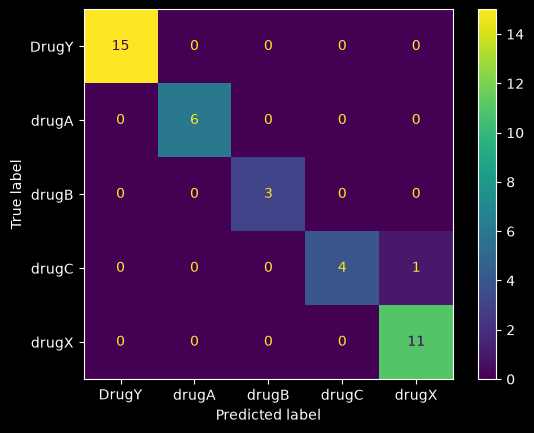

In [35]:
cm = confusion_matrix(y_test, preds, labels = pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
plt.savefig('Results/confusion_matrix.png')

In [37]:
sio.dump(pipe, 'Model/pipeline.skops')